In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib widget

In [2]:
from pathlib import Path
from cw.vdom import hyr, tabulate
from cw.filters import smooth_signal

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## List runs

In [52]:
results_path = Path('./results')

paths = {}

for group_path in results_path.glob("*"):
    group_data = []
    
    
    table = []
    for run_path in group_path.glob("*"):
        datetime, label = run_path.name.split("__")
        group_data.append([datetime, label, len(list(run_path.glob("*")))])
        
    paths[group_path.name] = tabulate(group_data)
    
hyr(paths)

2022_09_26_15_00_12_462654,,1
2022_10_20_23_19_15_209336,,1
2022_09_26_02_10_10_980819,,1
2022_10_13_03_34_09_039506,,5
2022_10_13_03_24_28_348092,,1
2022_10_13_03_49_03_027598,opt_1,8000
2022_09_26_02_00_15_466875,sigmoid_cost_function_2,179
2022_09_26_01_44_05_317308,sigmoid_cost_function_2,50
2022_09_26_15_05_57_028847,sigmoid_cost_function_2,355
2022_09_26_02_33_22_253118,sigmoid_cost_function_2,125
2022_09_26_02_03_26_249906,sigmoid_cost_function_2,800


In [80]:
## Explore run
group = "pso"
# run = "2022_10_13_03_49_03_027598	opt_1".replace("\t", "__")
run = "2022_10_13_03_49_03_027598	opt_1".replace("\t", "__")
run_path = results_path / group / run

list_log = []
for batch_log in run_path.glob("*"):
    # print(batch_log)
    list_log.append(np.load(batch_log))
    
list_log = np.vstack(list_log)

log = pd.DataFrame()

log['time'] = list_log[:, 1]
log['cost'] = list_log[:, 0]
log['case_inputs'] = [tuple(row) for row in list_log[:, 2:]]
log = log.sort_values("time")
hyr(log)

,time,cost,case_inputs
68572,1.665626e+09,0.999644,"(774.6989609916326, 568.5016009020128, 266.130..."
68573,1.665626e+09,0.999644,"(44.68162124806319, 743.8248580910515, 154.240..."
95561,1.665626e+09,0.999644,"(153.72088719260157, 221.7465718023668, 842.57..."
43582,1.665626e+09,0.999644,"(406.910809910256, 222.98110412515493, 409.383..."
68574,1.665626e+09,0.999644,"(460.674801391441, 886.9090802797957, 906.6499..."
...,...,...,...
82179,1.665642e+09,0.999642,"(391.55192619742843, 521.5356537421403, 480.93..."
40211,1.665642e+09,0.157870,"(397.6504641791175, 573.9384074887051, 464.617..."
40212,1.665642e+09,0.059245,"(397.6548363877506, 574.4818945081296, 464.459..."
40213,1.665642e+09,0.999644,"(396.9900545139636, 583.5015807114025, 464.760..."


100000


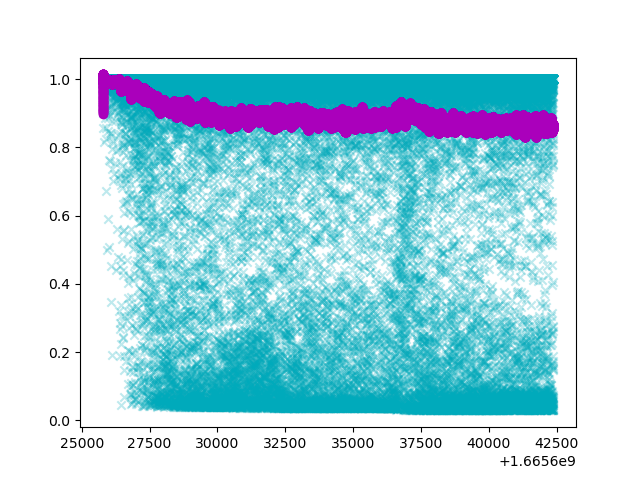

In [81]:
plt.close("all")
plt.figure()

# selected = log.sort_values("cost")[:100].sort_values("time")
selected = log[log.cost < 1.9]
# selected = log
print(len(selected))

# colors = np.array(selected.case_inputs.apply((lambda x: [sum(x[0:3:7]), sum(x[1:3:8]), sum(x[2:3:9]), 0.3])).values.tolist())
# colors[:, 0] = colors[:, 0] - min(colors[:, 0]) 
# colors[:, 1] = colors[:, 1] - min(colors[:, 1]) 
# colors[:, 2] = colors[:, 2] - min(colors[:, 2]) 

# colors[:, 0] = colors[:, 0] / max(colors[:, 0])
# colors[:, 1] = colors[:, 1] / max(colors[:, 1])
# colors[:, 2] = colors[:, 2] / max(colors[:, 2])
                
# colors = np.apply_along_axis(lambda x: f"#{int(x[0]):02x}{int(x[1]):02x}{int(x[2]):02x}", axis=1, arr=colors)

# print(colors[0])


plt.scatter(selected.time, selected.cost, marker="x", color="#00AABB41") #, color=colors.tolist())
plt.scatter(selected.time, smooth_signal(selected.cost.values), color="#AA00BB")

# tabulate([list(row) for row in selected['case_inputs'].values])

In [82]:
print(selected.sort_values("cost").case_inputs.values[0])
selected.sort_values("cost")
# tabulate([list(row) for row in selected.sort_values("cost").case_inputs.values])

(397.6653126795357, 574.3611173045505, 464.32248021339717, 614.103139656967, 395.2799706854334, 0.8438494583430421, 0.15164623248366033, -0.3057226286010565, 0.02503387878443818)


,time,cost,case_inputs
40708,1.665642e+09,0.028988,"(397.6653126795357, 574.3611173045505, 464.322..."
58964,1.665642e+09,0.029005,"(397.65714364287345, 574.4431631819601, 464.36..."
30585,1.665642e+09,0.029035,"(397.67106545986474, 574.3982767033572, 464.26..."
38728,1.665642e+09,0.029055,"(397.6451256728896, 574.4710033602979, 464.430..."
45122,1.665641e+09,0.029069,"(397.6564409544106, 574.556198022333, 464.7020..."
...,...,...,...
67906,1.665633e+09,0.999956,"(497.7642059318623, 594.3190841919917, 443.401..."
32482,1.665626e+09,0.999956,"(607.7700822881302, 332.3777346720426, 464.287..."
98973,1.665642e+09,0.999958,"(444.6849833606321, 479.27028727706016, 486.77..."
99957,1.665627e+09,0.999958,"(584.5048023636323, 607.5393156043956, 507.276..."


In [113]:
f"{3:02x}"

'03'